In [1]:
from __future__ import annotations
import random

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


In [2]:
def build_env(map_name: str = "8x8", slippery: bool = True):
	return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery,reward_schedule = (100,-50,-0))



In [3]:
def extract_model(env: gym.Env):
	n_states = env.observation_space.n
	n_actions = env.action_space.n
	transition = np.zeros((n_states, n_actions, n_states), dtype=float)
	reward = np.zeros((n_states, n_actions, n_states), dtype=float)

	for state in range(n_states):
		for action in range(n_actions):
			for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
				transition[state, action, next_state] += prob
				reward[state, action, next_state] = r

	expected_reward = np.sum(transition * reward, axis=2)
	return transition, reward, expected_reward


def q_values(transition, expected_reward, values, gamma):
	future = np.einsum("sat,t->sa", transition, values)
	return expected_reward + gamma * future

In [4]:
def policy_evaluation_monte_carlo(env, policy, gamma=0.99, episodes=100,max_steps=100):
	Q_values = np.zeros((env.observation_space.n, env.action_space.n,2))
	for episode in range(episodes):
		state = random.randint(0, env.observation_space.n - 1)
		action = random.randint(0, env.action_space.n - 1)
		env.reset()
		env.unwrapped.s = state
		done = False
		trajectory = []
		
		for i in range(max_steps):
			
			next_state, reward, done, _, _ = env.step(action)
			trajectory.append((state, action, reward))
			if done:
				break
			state = next_state
			action = policy[state]
		G = 0
		for state, action, reward in reversed(trajectory):
			G = reward + gamma * G
			Q_values[state, action, 0] += G
			Q_values[state, action, 1] += 1
	return Q_values[:,:,0] / np.maximum(Q_values[:,:,1], 1e-8)
			
			

In [5]:
def policy_iteration(env, gamma=0.99, max_iterations=1000):
	transition, reward, expected_reward = extract_model(env)
	policy = np.zeros(transition.shape[0], dtype=int)

	for iteration in range(max_iterations):
		q = policy_evaluation_monte_carlo(env, policy, gamma)
		new_policy = np.argmax(q, axis=1)
		if np.array_equal(new_policy, policy):
			return q, policy, iteration + 1
		policy = new_policy

	q = policy_evaluation_monte_carlo(env, policy, gamma)
	print(q)
	return q, policy, max_iterations



In [6]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()



FrozenLake-v1 8x8 model
states: 64, actions: 4
Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action
[[  0.          87.7521023   87.7521023   86.87458128]
 [  0.          88.63848717   0.          87.7521023 ]
 [  0.          89.53382543   0.           0.        ]
 [  0.           0.          90.4382075    0.        ]
 [  0.           0.          91.35172475   0.        ]
 [  0.          92.27446944  92.27446944  91.35172475]
 [  0.          93.20653479   0.           0.        ]
 [  0.           0.           0.           0.        ]
 [  0.           0.          88.63848717  86.87458128]
 [  0.          89.53382543   0.          87.7521023 ]
 [  0.          90.4382075    0.          88.63848717]
 [  0.           0.          91.35172475   0.        ]
 [ 90.4382075   92.27446944  92.27446944   0.        ]
 [  0.          93.20653479   0.           0.        ]
 [ 92.27446944  94.14801494   0.           0.        ]
 [ 93.20653479  93.20653479   0.           0.        ]
 [ 88.638

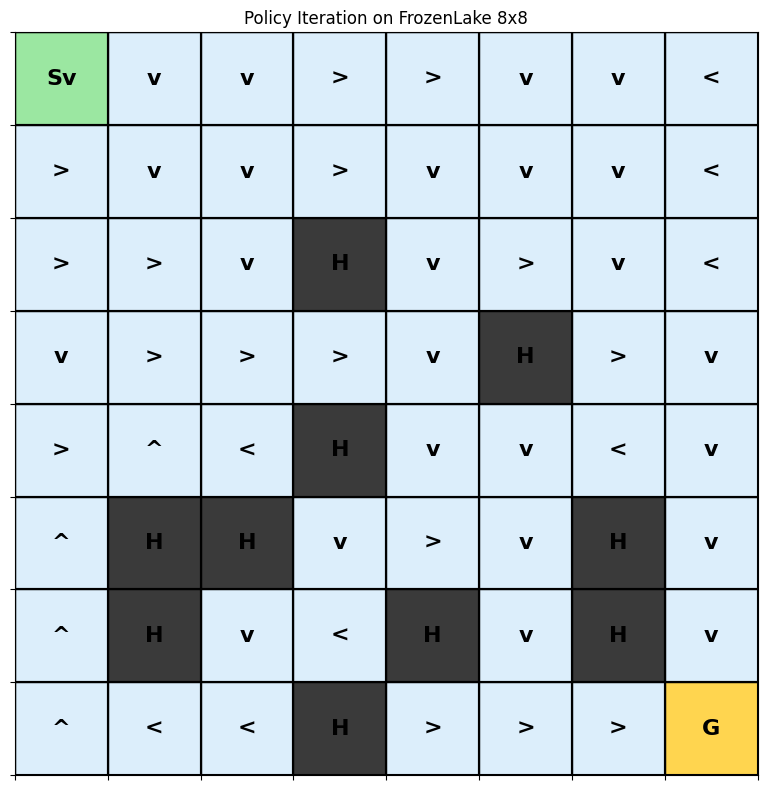

In [7]:
gamma = 0.99
env = build_env(slippery=False)
transition, reward, expected_reward = extract_model(env)

print("FrozenLake-v1 8x8 model")
print(f"states: {transition.shape[0]}, actions: {transition.shape[1]}")
print("Legend: S=start, F=frozen, H=hole, G=goal, arrow=optimal action")



q, pi_policy, _ = policy_iteration(env, gamma=gamma)
print(q)


plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration on FrozenLake 8x8")
